In [86]:
import os

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    api_key = input("Please enter your open ai api key").strip()
    os.environ["OPENAI_API_KEY"] = api_key
    if not api_key:
        raise EnvironmentError("No API Key provided")

In [87]:
import langgraph
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages
from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI
import random
import json
import inspect
import instructor
import ast


# Simple Node graph

In [88]:
from utils.utils import get_tool_descriptions, format_ai_message

import importlib
import utils.utils
importlib.reload(utils.utils)
from utils.utils import get_tool_descriptions, format_ai_message



In [89]:
from pydantic import Field
class ToolCall(BaseModel):
    name: str
    arguments: str



class AgentRespone(BaseModel):
    answer: str
    tool_calls: List[ToolCall] = Field(default_factory=list)


class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    message: str = ""
    iteration: int = 0
    answer: str = ""
    available_tools: List[Dict[str, Any]] = []
    tool_calls: List[ToolCall] = []

In [ ]:
def agent_node(state: State) -> dict:
    prompt_template = """
You are assistant that will generate vibes for the user.
You will be given selection of tools you can use to add vibes to the user query

<Available tools>
{{available_tools | tojson}}
</Available tools>

When you need to use a tool, format the response as:

<tool call>
{"name": "tool_name", "arguments": {...}}
</tool call>

Instructions:
- You need to use tool to add vibes to the user query
-  Add a random vibe to user query
"""
    template = Template(prompt_template)

    prompt = template.render(
        available_tools=state.available_tools
    )
    messages = state.message
    conversation = convert_to_openai_messages(messages)

    client = instructor.from_openai(OpenAI())

    response, raw_response = client.chat.completions.create_with_completion(
        model = 'gpt-4.1-mini',
        response_model=AgentRespone,
        messages=[{"role": "system",
                   "content": prompt},
                    *conversation],
        temperature=0.5


    )

    ai_message  = format_ai_message(response)
    return  {
        'messages': [ai_message],
        "tool_calls": response.tool_calls,
        "iteration": state.iteration + 1,
        "answer": response.answer
    }

In [91]:
def append_vibes(query: str, vibe: str) -> dict:
    """ Take in query and vibe and return string with the query and vibe appended """
    return f"{query} {vibe}"

In [92]:
def tool_router(state: State):
    if state.iteration > 1:
        return "end"
    if len(state.tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [93]:
from langgraph.prebuilt import ToolNode

workflow = StateGraph(State)
tools = [append_vibes]
tool_node = ToolNode(tools)


tool_description = get_tool_descriptions(tools)

workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)

workflow.add_edge(START, "agent_node")
workflow.add_conditional_edges("agent_node",
                               tool_router,
                               {
                                   "tools": "tool_node",
                                   "end": END
                               }
                               )
workflow.add_edge("tool_node", "agent_node")



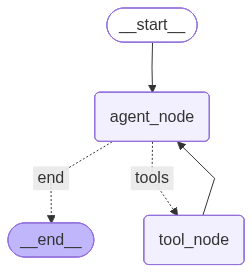

In [94]:
graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [95]:
inital_state = {
    "message": "Give me some vibe",
    "available_tools": tool_description
}


In [96]:
results = graph.invoke(inital_state)


TypeError: string indices must be integers, not 'str'

In [ ]:
results

{'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibe', 'vibe': 'chill and positive'}, 'id': 'call_0', 'type': 'tool_call'}]),
  ToolMessage(content='Give me some vibe chill and positive', name='append_vibes', tool_call_id='call_0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'Give me some vibe', 'vibe': 'chill and positive'}, 'id': 'call_0', 'type': 'tool_call'}])],
 'message': 'Give me some vibe',
 'iteration': 2,
 'answer': '',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Take in query and vibe and return string with the query and vibe appended',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string', 'description': ''},
     'vibe': {'type': 'string', 'description': ''}}},
   'required': ['query', 'vibe'],
   'returns': {'type': 'object', 'description': ''}}]